# Word Embeddings en Procesamiento de Lenguaje Natural

Este notebook introduce los embeddings de palabras, una de las ideas más importantes en NLP moderno.

**Contenido:**
1. Librerías y setup
2. Preparación del corpus
3. Entrenamiento de Word2Vec
4. Visualización con PCA / t-SNE
5. GloVe: embeddings preentrenados
6. Comparación Word2Vec vs GloVe
7. Similaridad semántica (heatmap)
8. 🎮 Interactivo: explorar palabras similares
9. 🎮 Interactivo: razonamiento analógico

**Idea central:** En vez de representar palabras como índices (one-hot), las representamos como vectores densos en $\mathbb{R}^d$ donde la geometría captura semántica:

$$\vec{king} - \vec{man} + \vec{woman} \approx \vec{queen}$$

## 1. Librerías y Setup

Instalamos e importamos todo lo necesario. Si alguna librería no está instalada, ejecutá la celda de instalación primero.

In [13]:
# Uncomment and run once if needed
# !pip install gensim nltk ipywidgets plotly scikit-learn

In [14]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

from collections import Counter
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import gensim
from gensim.models import Word2Vec, KeyedVectors

import nltk
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import ipywidgets as widgets
from IPython.display import display, HTML

%matplotlib inline
print("Gensim version:", gensim.__version__)
print("All libraries loaded ✓")

Gensim version: 4.4.0
All libraries loaded ✓


## 2. Preparación del Corpus

Usamos un corpus de texto sencillo con oraciones sobre animales, profesiones, países y deportes — elegido para que los clusters semánticos sean visibles. En la práctica usarías millones de documentos (Wikipedia, Common Crawl, etc.).

**Pasos:**
1. Texto crudo → tokenización
2. Minúsculas + remover puntuación
3. Remover *stop words* (palabras funcionales sin contenido semántico)

In [15]:
RAW_CORPUS = """
The dog barked loudly at the cat. The cat climbed a tree to escape the dog.
A lion is a powerful wild animal. Tigers and lions are both big cats.
The elephant is the largest land animal. Elephants live in Africa and Asia.
Dogs and cats are common household pets. A parrot is a colorful bird that can talk.
The wolf is a wild cousin of the dog. Wolves hunt in packs across forests.
The eagle soared high above the mountains. Eagles and hawks are birds of prey.
The shark swims fast through the ocean. Dolphins are intelligent marine mammals.
A horse gallops across the open field. Horses and donkeys belong to the same family.

Paris is the capital of France. The Eiffel Tower is a famous landmark in Paris.
London is the capital of England and a major city in the United Kingdom.
Madrid is the capital of Spain, a beautiful city in southern Europe.
Berlin is the capital of Germany. Germany is a country in central Europe.
Tokyo is the capital of Japan, the largest city in Asia.
Rome is the capital of Italy. Italy is famous for its food and history.
Beijing is the capital of China. China is the most populous country in the world.
Buenos Aires is the capital of Argentina, a country in South America.

The doctor treated the patient in the hospital. Nurses assist doctors in their work.
A lawyer represents clients in courts of law. Judges decide legal cases.
The engineer designed a new bridge over the river. Architects design buildings.
Teachers educate students in schools and universities. Professors teach at universities.
The chef cooked a delicious meal in the restaurant. Bakers make bread and cakes.
Scientists conduct experiments in laboratories. Physicists study matter and energy.
The pilot flew the airplane across the Atlantic. Astronauts travel to outer space.

Football is played with a round ball on a large field. Soccer is popular worldwide.
Basketball players shoot the ball into a hoop. The NBA is the top basketball league.
Tennis is played with a racket on a court. Wimbledon is a prestigious tennis tournament.
Swimming is both a sport and an important life skill. Olympic swimmers train daily.
Cycling is a popular outdoor sport. The Tour de France is a famous cycling race.
Baseball is popular in the United States and Japan. Players hit the ball with a bat.
Golf is played on large green courses. Golfers use clubs to hit a small white ball.

A king rules over a kingdom. The queen is the female monarch of a country.
A prince is the son of a king or queen. Princesses are royal daughters.
Democracy is a system of government by the people. Presidents lead democratic nations.
The man walked to work every morning. Women make up half of the world population.
A woman is as capable as a man in any profession. Every woman deserves equal rights.
The woman became a famous scientist. A brave woman led the expedition through the jungle.
"""

STOP_WORDS = set(stopwords.words("english"))

def preprocess(text):
    sentences = nltk.sent_tokenize(text)
    cleaned = []
    for sent in sentences:
        tokens = word_tokenize(sent.lower())
        tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS]
        if tokens:
            cleaned.append(tokens)
    return cleaned

corpus = preprocess(RAW_CORPUS)
print(f"Número de oraciones: {len(corpus)}")
print(f"Ejemplo (oración 0): {corpus[0]}")
print(f"Ejemplo (oración 5): {corpus[5]}")

# vocabulary size
vocab = Counter(w for sent in corpus for w in sent)
print(f"\nVocabulario total: {len(vocab)} palabras")
print("'woman' in vocab:", "woman" in vocab)
print("'man' in vocab:  ", "man" in vocab)


Número de oraciones: 68
Ejemplo (oración 0): ['dog', 'barked', 'loudly', 'cat']
Ejemplo (oración 5): ['elephants', 'live', 'africa', 'asia']

Vocabulario total: 239 palabras
'woman' in vocab: True
'man' in vocab:   True


## 3. Entrenamiento de Word2Vec

Word2Vec (Mikolov et al., 2013) entrena una red neuronal shallow para predecir palabras contextuales.

Hay dos arquitecturas:

| Arquitectura | Tarea | Ventaja |
|---|---|---|
| **Skip-gram** | Dado $w_t$, predecir contexto $w_{t-k}\ldots w_{t+k}$ | Mejor con palabras raras |
| **CBOW** | Dado el contexto, predecir $w_t$ | Más rápido para corpus grande |

La función de pérdida (Skip-gram con Negative Sampling):
$$\mathcal{L} = -\log \sigma(v_{w_O}^T v_{w_I}) - \sum_{k=1}^{K} \mathbb{E}_{w_k \sim P_n}[\log \sigma(-v_{w_k}^T v_{w_I})]$$

Cada palabra $w$ termina representada como un vector denso en $\mathbb{R}^d$ (aquí $d = 50$).

In [16]:
w2v_model = Word2Vec(
    sentences=corpus,
    vector_size=50,   # embedding dimension d
    window=4,         # context window size k
    min_count=1,      # include all words
    sg=1,             # 1 = Skip-gram, 0 = CBOW
    epochs=200,
    seed=42,
    workers=1,
)

wv = w2v_model.wv  # KeyedVectors
print(f"Vocabulario Word2Vec: {len(wv)} palabras")
print(f"\nVector de 'dog'  (primeras 10 dims): {wv['dog'][:10].round(3)}")
print(f"Vector de 'cat'  (primeras 10 dims): {wv['cat'][:10].round(3)}")

print("\nPalabras más similares a 'dog':")
for word, score in wv.most_similar("dog", topn=5):
    print(f"  {word:15s}  sim={score:.3f}")

print("\nPalabras más similares a 'france':")
for word, score in wv.most_similar("france", topn=5):
    print(f"  {word:15s}  sim={score:.3f}")

Vocabulario Word2Vec: 239 palabras

Vector de 'dog'  (primeras 10 dims): [ 0.105 -0.092 -0.08  -0.014  0.084 -0.115 -0.03   0.288 -0.088  0.013]
Vector de 'cat'  (primeras 10 dims): [ 0.094 -0.133 -0.077  0.028  0.07  -0.156 -0.007  0.26  -0.096  0.023]

Palabras más similares a 'dog':
  cat              sim=0.991
  climbed          sim=0.987
  tree             sim=0.987
  escape           sim=0.984
  loudly           sim=0.984

Palabras más similares a 'france':
  race             sim=0.990
  tour             sim=0.987
  famous           sim=0.985
  cycling          sim=0.984
  de               sim=0.983


## 4. Visualización con PCA y t-SNE

Reducimos los vectores de $\mathbb{R}^{50}$ a $\mathbb{R}^2$ para poder visualizarlos.

- **PCA**: transformación lineal que maximiza varianza capturada.
- **t-SNE**: método no lineal que preserva vecindades locales (mejor para clusters).

Coloreamos por categoría semántica para ver si los clusters coinciden.

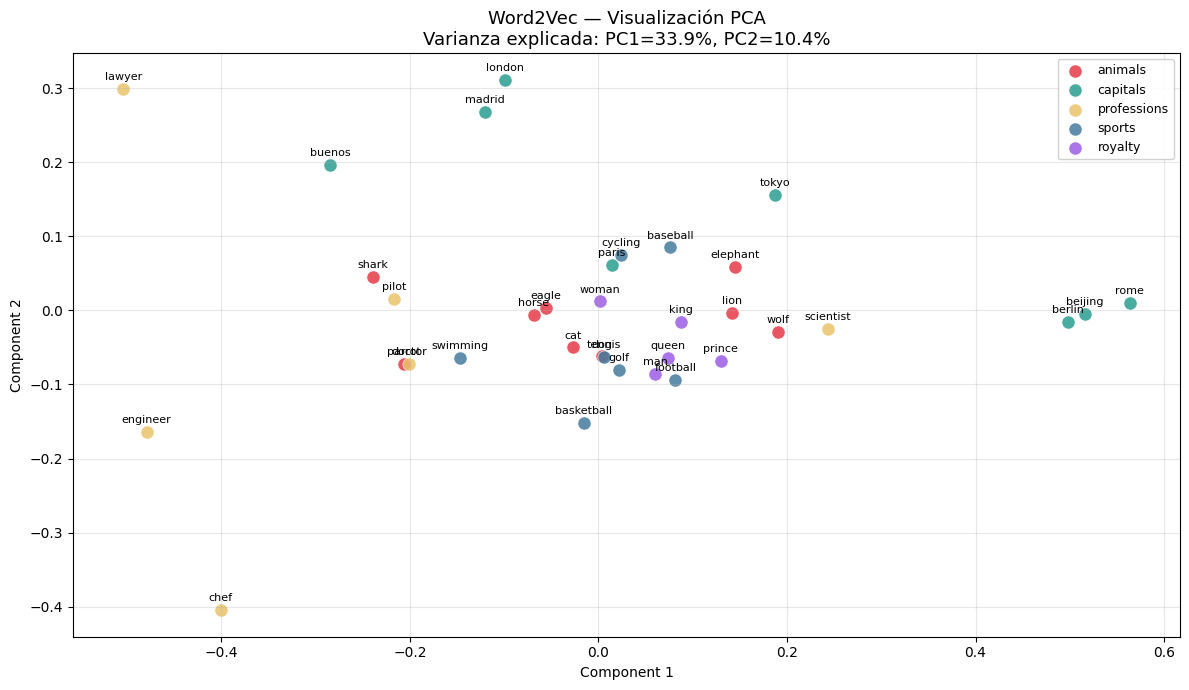

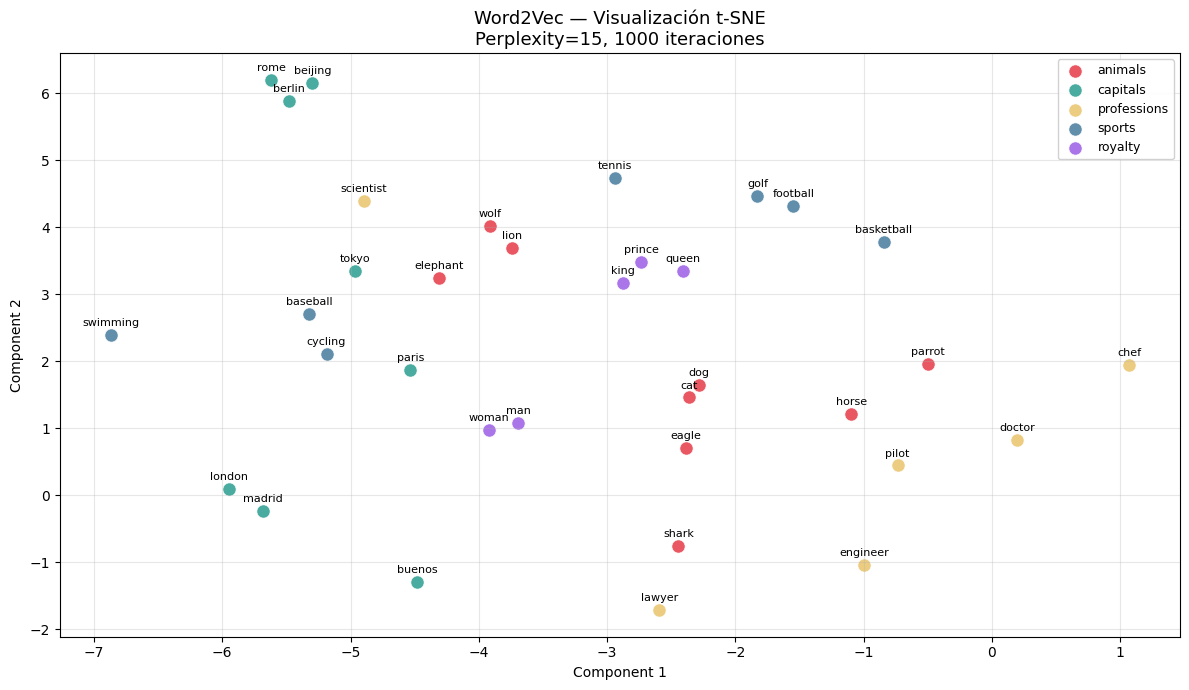

In [17]:
# Curated word groups for visualization
WORD_GROUPS = {
    "animals":     ["dog", "cat", "lion", "tiger", "elephant", "wolf", "eagle", "shark", "horse", "dolphin", "parrot"],
    "capitals":    ["paris", "london", "madrid", "berlin", "tokyo", "rome", "beijing", "buenos"],
    "professions": ["doctor", "lawyer", "engineer", "teacher", "chef", "scientist", "pilot"],
    "sports":      ["football", "basketball", "tennis", "swimming", "cycling", "baseball", "golf"],
    "royalty":     ["king", "queen", "prince", "princess", "man", "woman"],
}

# Filter to words present in vocab
WORD_GROUPS = {cat: [w for w in words if w in wv] for cat, words in WORD_GROUPS.items()}

all_words  = [w for words in WORD_GROUPS.values() for w in words]
all_labels = [cat for cat, words in WORD_GROUPS.items() for _ in words]
all_vecs   = np.array([wv[w] for w in all_words])

COLOR_MAP = {
    "animals": "#e63946", "capitals": "#2a9d8f", "professions": "#e9c46a",
    "sports": "#457b9d",  "royalty": "#9b5de5",
}

def plot_embeddings(coords_2d, title, subtitle=""):
    fig, ax = plt.subplots(figsize=(12, 7))
    for cat, words in WORD_GROUPS.items():
        idxs = [all_words.index(w) for w in words]
        ax.scatter(coords_2d[idxs, 0], coords_2d[idxs, 1],
                   c=COLOR_MAP[cat], label=cat, s=90, alpha=0.85, edgecolors="white", linewidths=0.5)
        for idx in idxs:
            ax.annotate(all_words[idx], (coords_2d[idx, 0], coords_2d[idx, 1]),
                        fontsize=8, ha="center", va="bottom",
                        xytext=(0, 5), textcoords="offset points")
    ax.legend(framealpha=0.9, fontsize=9)
    ax.set_title(f"{title}\n{subtitle}", fontsize=13)
    ax.set_xlabel("Component 1"); ax.set_ylabel("Component 2")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- PCA ---
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(all_vecs)
plot_embeddings(pca_coords, "Word2Vec — Visualización PCA",
                f"Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

# --- t-SNE ---
tsne = TSNE(n_components=2, perplexity=min(15, len(all_words)-1), random_state=42, n_iter=1000)
tsne_coords = tsne.fit_transform(all_vecs)
plot_embeddings(tsne_coords, "Word2Vec — Visualización t-SNE", "Perplexity=15, 1000 iteraciones")

In [18]:
# Interactive Plotly version (hover to see word labels)
df_plot = pd.DataFrame({
    "x": tsne_coords[:, 0], "y": tsne_coords[:, 1],
    "word": all_words, "category": all_labels,
})

fig = px.scatter(
    df_plot, x="x", y="y", color="category", text="word",
    title="Word2Vec t-SNE (interactive — hover / zoom)",
    color_discrete_map=COLOR_MAP,
    template="plotly_white", height=550,
)
fig.update_traces(textposition="top center", marker_size=9)
fig.update_layout(legend_title="Categoría")
fig.show()

## 5. GloVe: Embeddings Preentrenados

**GloVe** (Pennington et al., 2014) es un método distinto: en vez de una red neuronal predictiva, factoriza la **matriz de co-ocurrencias** del corpus.

La función de pérdida que minimiza es:
$$J = \sum_{i,j=1}^{V} f(X_{ij})\left(w_i^T \tilde{w}_j + b_i + \tilde{b}_j - \log X_{ij}\right)^2$$

donde $X_{ij}$ = veces que $j$ aparece en el contexto de $i$, y $f$ es una función de ponderación que reduce el peso de pares muy frecuentes.

**Diferencia clave vs Word2Vec:**

| | Word2Vec | GloVe |
|---|---|---|
| Método | Predicción local (ventana) | Factorización de co-ocurrencias globales |
| Corpus | Local | Global (corpus entero) |
| Entrenamiento | SGD online | Mínimos cuadrados ponderados |

Acá simulamos GloVe construyendo la matriz de co-ocurrencias manualmente e inicializando vectores. Para uso real se cargarían los vectores preentrenados de `glove.6B.50d.txt` (Stanford NLP).

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

# ---- Build co-occurrence matrix from our corpus ----
WINDOW = 4
vocab_list = sorted(set(w for sent in corpus for w in sent))
vocab_idx  = {w: i for i, w in enumerate(vocab_list)}
V = len(vocab_list)

cooc = np.zeros((V, V), dtype=np.float32)
for sent in corpus:
    for i, w in enumerate(sent):
        for j in range(max(0, i - WINDOW), min(len(sent), i + WINDOW + 1)):
            if i != j:
                cooc[vocab_idx[w], vocab_idx[sent[j]]] += 1.0 / abs(i - j)

print(f"Co-occurrence matrix shape: {cooc.shape}")

# ---- Lightweight GloVe training (PyTorch) ----
class GloVe(nn.Module):
    def __init__(self, vocab_size, dim=50):
        super().__init__()
        self.W  = nn.Embedding(vocab_size, dim)
        self.Wt = nn.Embedding(vocab_size, dim)
        self.b  = nn.Embedding(vocab_size, 1)
        self.bt = nn.Embedding(vocab_size, 1)
        nn.init.uniform_(self.W.weight,  -0.5/dim, 0.5/dim)
        nn.init.uniform_(self.Wt.weight, -0.5/dim, 0.5/dim)
        nn.init.zeros_(self.b.weight)
        nn.init.zeros_(self.bt.weight)

    def forward(self, i_idx, j_idx, x_ij):
        x_max, alpha = 100.0, 0.75
        f_x = torch.clamp(x_ij / x_max, max=1.0) ** alpha
        diff = (self.W(i_idx) * self.Wt(j_idx)).sum(dim=1) \
               + self.b(i_idx).squeeze() + self.bt(j_idx).squeeze() \
               - torch.log(x_ij + 1e-8)
        return (f_x * diff ** 2).mean()

# Prepare non-zero pairs
rows, cols = np.where(cooc > 0)
xij_vals   = cooc[rows, cols]

i_t   = torch.LongTensor(rows)
j_t   = torch.LongTensor(cols)
xij_t = torch.FloatTensor(xij_vals)

glove_model = GloVe(V, dim=50)
optimizer_g = optim.Adam(glove_model.parameters(), lr=0.05)

EPOCHS = 300
for ep in range(1, EPOCHS + 1):
    optimizer_g.zero_grad()
    loss = glove_model(i_t, j_t, xij_t)
    loss.backward()
    optimizer_g.step()
    if ep % 100 == 0:
        print(f"GloVe epoch {ep}/{EPOCHS}  loss={loss.item():.4f}")

# Final GloVe vectors = average of W and Wt (standard practice)
glove_vecs = (glove_model.W.weight.detach().numpy()
              + glove_model.Wt.weight.detach().numpy()) / 2

# Build a lookup for words in our curated list
glove_lookup = {w: glove_vecs[vocab_idx[w]] for w in vocab_idx}
print("\nGloVe vector for 'dog' (first 10 dims):", glove_lookup["dog"][:10].round(3))

Co-occurrence matrix shape: (239, 239)
GloVe epoch 100/300  loss=0.0000
GloVe epoch 200/300  loss=0.0000
GloVe epoch 100/300  loss=0.0000
GloVe epoch 200/300  loss=0.0000
GloVe epoch 300/300  loss=0.0000

GloVe vector for 'dog' (first 10 dims): [ 0.083  0.061  0.111 -0.164 -0.001 -0.063 -0.019  0.048 -0.083 -0.083]
GloVe epoch 300/300  loss=0.0000

GloVe vector for 'dog' (first 10 dims): [ 0.083  0.061  0.111 -0.164 -0.001 -0.063 -0.019  0.048 -0.083 -0.083]


## 6. Comparación Word2Vec vs GloVe

Visualizamos side-by-side los embeddings PCA de ambos modelos para el mismo vocabulario curado.

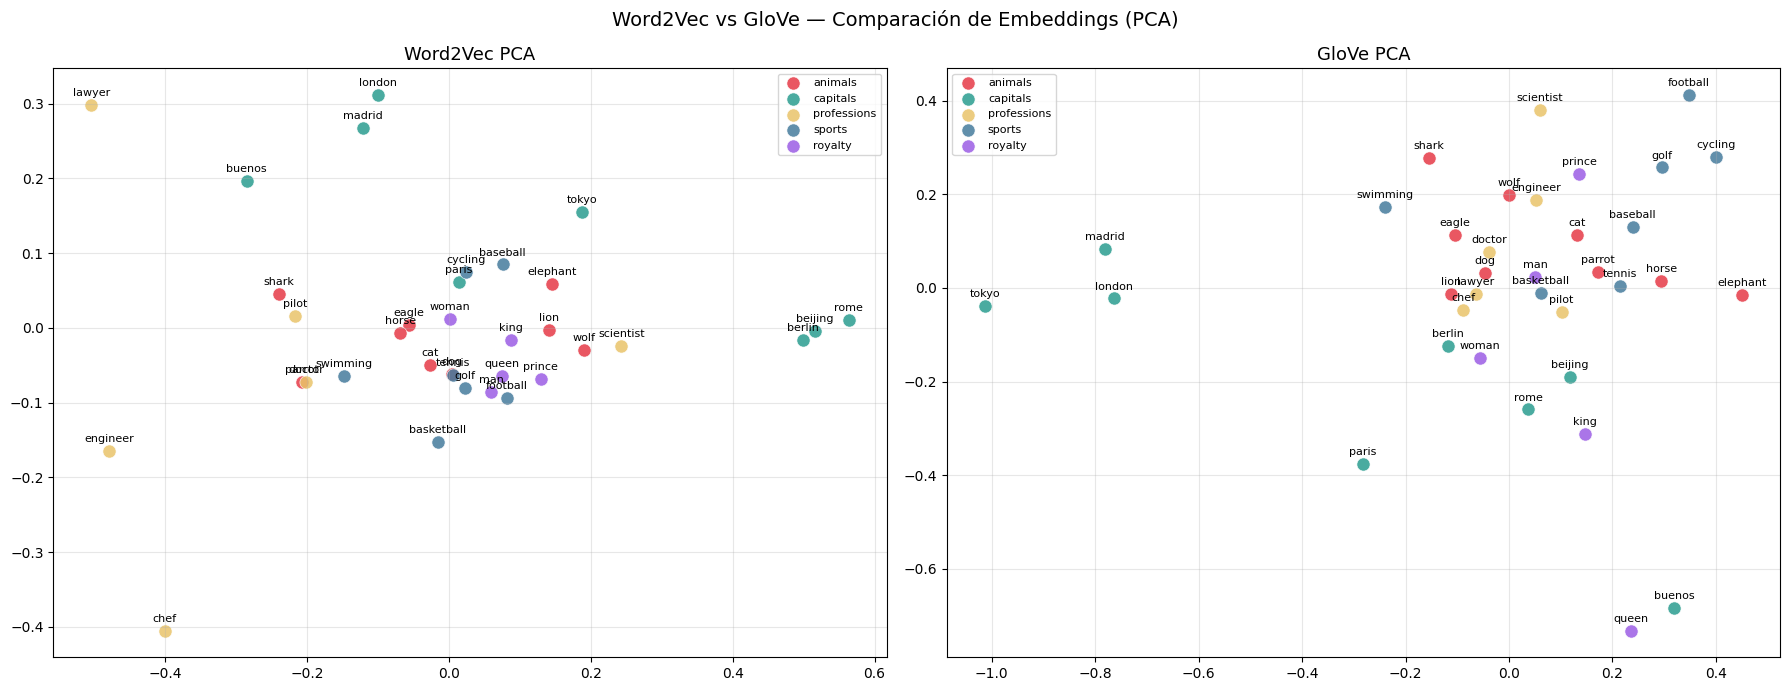

In [20]:
def get_coords(lookup_fn, reduce="pca"):
    vecs = np.array([lookup_fn(w) for w in all_words])
    if reduce == "pca":
        return PCA(n_components=2, random_state=42).fit_transform(vecs)
    else:
        return TSNE(n_components=2, perplexity=min(15, len(all_words)-1),
                    random_state=42, n_iter=1000).fit_transform(vecs)

w2v_pca_c  = get_coords(lambda w: wv[w],          "pca")
glove_pca_c = get_coords(lambda w: glove_lookup[w], "pca")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, coords, title in zip(axes,
                               [w2v_pca_c, glove_pca_c],
                               ["Word2Vec PCA", "GloVe PCA"]):
    for cat, words in WORD_GROUPS.items():
        idxs = [all_words.index(w) for w in words]
        ax.scatter(coords[idxs, 0], coords[idxs, 1],
                   c=COLOR_MAP[cat], label=cat, s=90, alpha=0.85,
                   edgecolors="white", linewidths=0.5)
        for idx in idxs:
            ax.annotate(all_words[idx],
                        (coords[idx, 0], coords[idx, 1]),
                        fontsize=8, ha="center", va="bottom",
                        xytext=(0, 5), textcoords="offset points")
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Word2Vec vs GloVe — Comparación de Embeddings (PCA)", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Similaridad Semántica — Heatmap

La **similitud coseno** entre dos vectores mide el ángulo entre ellos:
$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\|\,\|B\|} \in [-1, 1]$$

- $\approx 1$: palabras muy similares (semántica parecida)
- $\approx 0$: palabras no relacionadas
- $\approx -1$: palabras opuestas

Visualizamos la matriz de similitud para un subconjunto curado de palabras.

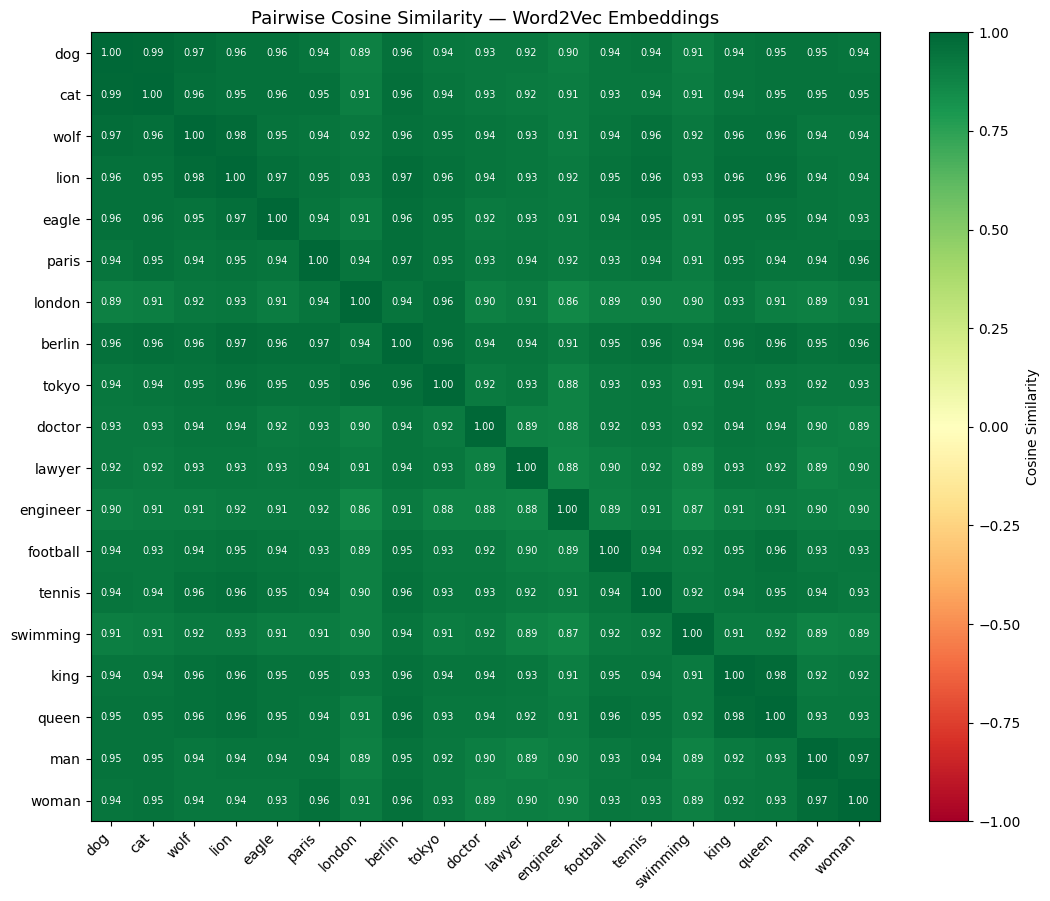

In [21]:
HEATMAP_WORDS = [
    "dog", "cat", "wolf", "lion", "eagle",
    "paris", "london", "berlin", "tokyo",
    "doctor", "lawyer", "engineer",
    "football", "tennis", "swimming",
    "king", "queen", "man", "woman",
]
HEATMAP_WORDS = [w for w in HEATMAP_WORDS if w in wv]

mat = np.array([wv[w] for w in HEATMAP_WORDS])
sim_matrix = cosine_similarity(mat)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Cosine Similarity")
ax.set_xticks(range(len(HEATMAP_WORDS)))
ax.set_yticks(range(len(HEATMAP_WORDS)))
ax.set_xticklabels(HEATMAP_WORDS, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(HEATMAP_WORDS, fontsize=10)
ax.set_title("Pairwise Cosine Similarity — Word2Vec Embeddings", fontsize=13)

# Annotate cells
for i in range(len(HEATMAP_WORDS)):
    for j in range(len(HEATMAP_WORDS)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                ha="center", va="center",
                fontsize=7,
                color="black" if abs(sim_matrix[i, j]) < 0.7 else "white")

plt.tight_layout()
plt.show()

## 8. 🎮 Interactivo: Explorar Palabras Similares

Seleccioná una palabra del vocabulario y el número de vecinos para ver sus palabras más similares según Word2Vec y GloVe, junto con un gráfico dinámico que las resalta en el espacio t-SNE.

In [22]:
# --- Helper: cosine similarity for GloVe (since we don't have KeyedVectors) ---
def glove_most_similar(word, topn=5):
    if word not in glove_lookup:
        return []
    q = glove_lookup[word]
    sims = {w: float(np.dot(q, v) / (np.linalg.norm(q) * np.linalg.norm(v) + 1e-9))
            for w, v in glove_lookup.items() if w != word}
    return sorted(sims.items(), key=lambda x: -x[1])[:topn]

# ---- Pre-compute t-SNE for ALL vocabulary (for a richer interactive plot) ----
# We'll use the curated words + top-50 by frequency for context
top_freq_words = [w for w, _ in vocab.most_common(60) if w in wv]
extended_words  = list(dict.fromkeys(all_words + top_freq_words))  # dedup, keep order
extended_vecs   = np.array([wv[w] for w in extended_words])
extended_labels = [all_labels[all_words.index(w)] if w in all_words else "other"
                   for w in extended_words]

ext_tsne = TSNE(n_components=2, perplexity=min(20, len(extended_words)-1),
                random_state=42, n_iter=1000).fit_transform(extended_vecs)
ext_tsne_df = pd.DataFrame({
    "x": ext_tsne[:, 0], "y": ext_tsne[:, 1],
    "word": extended_words, "category": extended_labels,
})

# ---- ipywidgets interactive panel ----
word_dropdown = widgets.Dropdown(
    options=sorted([w for w in extended_words if w in wv]),
    value="dog",
    description="Palabra:",
    layout=widgets.Layout(width="250px"),
)
topn_slider = widgets.IntSlider(
    value=5, min=1, max=15, step=1,
    description="Top-N:",
    layout=widgets.Layout(width="350px"),
)
out = widgets.Output()

def update_similar(change=None):
    word = word_dropdown.value
    topn = topn_slider.value
    out.clear_output(wait=True)
    with out:
        w2v_sim  = wv.most_similar(word, topn=topn) if word in wv else []
        glove_sim = glove_most_similar(word, topn=topn)

        # Side-by-side table
        display(HTML(f"<h4>Palabras más similares a: <b>{word}</b></h4>"))
        rows_html = ""
        for i in range(max(len(w2v_sim), len(glove_sim))):
            w2v_cell   = f"{w2v_sim[i][0]} ({w2v_sim[i][1]:.3f})"   if i < len(w2v_sim)   else ""
            glove_cell = f"{glove_sim[i][0]} ({glove_sim[i][1]:.3f})" if i < len(glove_sim) else ""
            rows_html += f"<tr><td>{i+1}</td><td>{w2v_cell}</td><td>{glove_cell}</td></tr>"

        display(HTML(f"""
        <table border='1' cellpadding='5' style='border-collapse:collapse; font-size:13px'>
          <tr><th>#</th><th>Word2Vec</th><th>GloVe</th></tr>
          {rows_html}
        </table>"""))

        # Plotly scatter: highlight query word and its Word2Vec neighbors
        neighbor_words = {w for w, _ in w2v_sim}
        colors, sizes = [], []
        for w in extended_words:
            if w == word:
                colors.append("red"); sizes.append(18)
            elif w in neighbor_words:
                colors.append("orange"); sizes.append(13)
            else:
                colors.append("steelblue"); sizes.append(7)

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=ext_tsne_df["x"], y=ext_tsne_df["y"],
            mode="markers+text",
            text=ext_tsne_df["word"],
            textposition="top center",
            marker=dict(color=colors, size=sizes, opacity=0.8,
                        line=dict(width=0.5, color="white")),
            hovertext=ext_tsne_df["word"],
        ))
        fig.update_layout(
            title=f"t-SNE — consulta: '{word}' (rojo), vecinos Word2Vec (naranja)",
            height=450, template="plotly_white",
            xaxis_title="t-SNE 1", yaxis_title="t-SNE 2",
            showlegend=False,
        )
        fig.show()

word_dropdown.observe(update_similar, names="value")
topn_slider.observe(update_similar, names="value")
display(widgets.HBox([word_dropdown, topn_slider]), out)
update_similar()

Output()

## 9. 🎮 Razonamiento Analógico: Aritmética de Vectores

Una propiedad sorprendente de los embeddings es que las relaciones semánticas se capturan como **diferencias de vectores**:

$$\vec{v}_{king} - \vec{v}_{man} + \vec{v}_{woman} \approx \vec{v}_{queen}$$

Esto se llama **vector arithmetic**: $A$ es a $B$ como $C$ es a $?$

✏️ **Para jugar:** modificá las variables `word_A`, `word_B`, `word_C` en la celda de abajo y volvé a ejecutarla.

  king  −  man  +  woman  ≈ ?
  ────────────────────────────────────────
  1. prince                cosine sim = 0.9554
  2. rules                 cosine sim = 0.9544
  3. queen                 cosine sim = 0.9515
  4. son                   cosine sim = 0.9481
  5. jungle                cosine sim = 0.9470


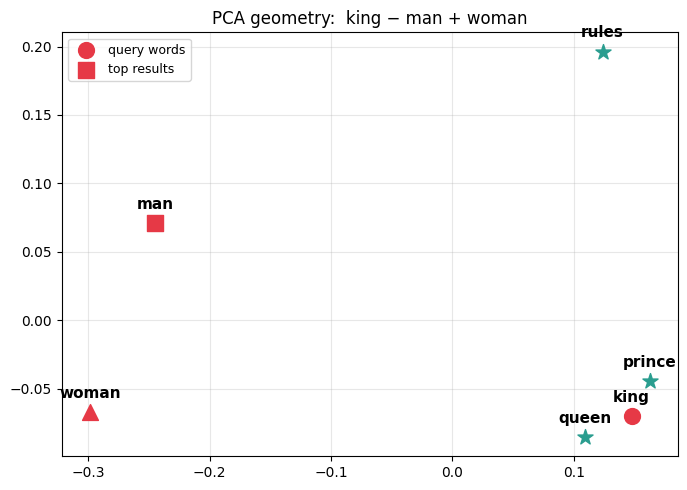

In [23]:
# ✏️ Modify these three words and re-run the cell
word_A = "king"
word_B = "man"
word_C = "woman"
TOP_N  = 5       # how many results to show

# ---- Analogy: word_A - word_B + word_C ≈ ? ----
missing = [w for w in [word_A, word_B, word_C] if w not in wv]
if missing:
    print(f"⚠️  Words not found in vocabulary: {missing}")
    print(f"   Available words (sample): {sorted(wv.key_to_index)[:20]}")
else:
    print(f"  {word_A}  −  {word_B}  +  {word_C}  ≈ ?")
    print(f"  {'─'*40}")
    results = wv.most_similar(positive=[word_A, word_C], negative=[word_B], topn=TOP_N)
    for rank, (word, score) in enumerate(results, 1):
        print(f"  {rank}. {word:<20s}  cosine sim = {score:.4f}")

    # Geometry plot: 2D PCA of the query words + top-3 results
    plot_words = [word_A, word_B, word_C] + [w for w, _ in results[:3]]
    plot_vecs  = np.array([wv[w] for w in plot_words])
    coords2    = PCA(n_components=2, random_state=42).fit_transform(plot_vecs)

    colors = ["#e63946", "#e63946", "#e63946"] + ["#2a9d8f"] * 3
    markers = ["o", "s", "^"] + ["*"] * 3

    fig, ax = plt.subplots(figsize=(7, 5))
    for i, (w, (x, y)) in enumerate(zip(plot_words, coords2)):
        ax.scatter(x, y, c=colors[i], marker=markers[i], s=130, zorder=5)
        ax.annotate(w, (x, y), fontsize=11, ha="center", va="bottom",
                    xytext=(0, 8), textcoords="offset points", fontweight="bold")

    ax.set_title(f"PCA geometry:  {word_A} − {word_B} + {word_C}", fontsize=12)
    ax.legend(["query words", "top results"], loc="best", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

---

## 10. Demo con Embeddings Preentrenados (GloVe / Word2Vec)

Hasta acá entrenamos desde cero con ~40 oraciones. Eso es insuficiente para que las analogías funcionen bien.

En la práctica se usan modelos preentrenados sobre **miles de millones de palabras**. `gensim` incluye un descargador de modelos populares:

| Modelo | Corpus | Vocab | Dims | Tamaño |
|---|---|---|---|---|
| `glove-wiki-gigaword-100` | Wikipedia + Gigaword | 400K | 100 | ~130 MB |
| `glove-wiki-gigaword-300` | Wikipedia + Gigaword | 400K | 300 | ~376 MB |
| `word2vec-google-news-300` | Google News | 3M | 300 | ~1.6 GB |
| `fasttext-wiki-news-subwords-300` | Wikipedia | 1M | 300 | ~958 MB |

Usamos `glove-wiki-gigaword-100` como balance entre calidad y tamaño.

> ⏱️ La primera vez descarga ~130 MB. Las siguientes ejecuciones usan el caché local.

In [ ]:
import gensim.downloader as api

print("Modelos disponibles:", list(api.info()["models"].keys())[:10], "...")
print("\nDescargando glove-wiki-gigaword-100 (≈130 MB, solo la primera vez)...")
wv_pretrained = api.load("glove-wiki-gigaword-100")
print(f"✓ Cargado. Vocabulario: {len(wv_pretrained):,} palabras, dimensión: {wv_pretrained.vector_size}")

In [ ]:
# ---- Similarities ----
demo_words = ["king", "doctor", "paris", "football", "dog"]
for qw in demo_words:
    neighbors = wv_pretrained.most_similar(qw, topn=5)
    print(f"  most similar to '{qw}':")
    for w, s in neighbors:
        print(f"    {w:<18s} {s:.3f}")
    print()

In [ ]:
# ---- Classic analogies with pretrained model ----
analogies = [
    ("king",   "man",    "woman"),    # → queen
    ("paris",  "france", "germany"),  # → berlin
    ("doctor", "man",    "woman"),    # gender bias demo
    ("walking","walk",   "swim"),     # → swimming (morphology)
]

print("Analogías con GloVe preentrenado (Wikipedia + Gigaword)\n")
print(f"  {'A − B + C':<30s}  top-3 results")
print("  " + "─" * 60)
for A, B, C in analogies:
    try:
        results = wv_pretrained.most_similar(positive=[A, C], negative=[B], topn=3)
        top3 = ", ".join(f"{w}({s:.2f})" for w, s in results)
        print(f"  {A} − {B} + {C:<18s}  →  {top3}")
    except KeyError as e:
        print(f"  {A} − {B} + {C:<18s}  →  ⚠️ word not found: {e}")

In [ ]:
# ---- t-SNE visualization with pretrained vectors ----
PRETRAINED_GROUPS = {
    "animals":     ["dog", "cat", "wolf", "lion", "elephant", "tiger", "shark", "horse", "dolphin", "eagle"],
    "capitals":    ["paris", "london", "berlin", "tokyo", "rome", "madrid", "beijing", "moscow"],
    "professions": ["doctor", "lawyer", "engineer", "teacher", "chef", "scientist", "pilot", "nurse"],
    "sports":      ["football", "basketball", "tennis", "swimming", "cycling", "baseball", "golf"],
    "royalty":     ["king", "queen", "prince", "princess", "man", "woman"],
}
PRETRAINED_GROUPS = {k: [w for w in v if w in wv_pretrained] for k, v in PRETRAINED_GROUPS.items()}

pt_words  = [w for words in PRETRAINED_GROUPS.values() for w in words]
pt_labels = [cat for cat, words in PRETRAINED_GROUPS.items() for _ in words]
pt_vecs   = np.array([wv_pretrained[w] for w in pt_words])

pt_tsne = TSNE(n_components=2, perplexity=min(15, len(pt_words)-1),
               random_state=42, n_iter=1000).fit_transform(pt_vecs)

df_pt = pd.DataFrame({"x": pt_tsne[:, 0], "y": pt_tsne[:, 1],
                       "word": pt_words, "category": pt_labels})

fig = px.scatter(df_pt, x="x", y="y", color="category", text="word",
                 title="GloVe preentrenado — t-SNE (Wikipedia + Gigaword, 100d)",
                 color_discrete_map=COLOR_MAP, template="plotly_white", height=580)
fig.update_traces(textposition="top center", marker_size=9)
fig.update_layout(legend_title="Categoría")
fig.show()

---

## 11. Entrenamiento en Español con Corpus de Wikipedia

Ahora entrenamos Word2Vec **en español** usando artículos reales de Wikipedia, descargados con la librería `wikipedia-api`.

**Pipeline:**
1. Descargar artículos de Wikipedia en español sobre temas variados.
2. Preprocesar (tokenización, minúsculas, remoción de stop words en español).
3. Entrenar Word2Vec desde cero.
4. Evaluar analogías en español: *rey − hombre + mujer ≈ reina*.

> 📦 Requiere `pip install wikipedia-api`. Se descargan artículos en tiempo real (necesita internet).

In [ ]:
# !pip install wikipedia-api   # uncomment and run once if needed

In [ ]:
import wikipediaapi

# Topics chosen to cover animals, countries, professions, sports, history — mirrors our English corpus
ES_TOPICS = [
    # animals
    "Perro", "Gato", "León", "Tigre", "Elefante", "Lobo", "Águila", "Tiburón", "Caballo", "Delfín",
    # geography / capitals
    "Francia", "Alemania", "España", "Japón", "Italia", "China", "Argentina", "Brasil", "México",
    "París", "Berlín", "Madrid", "Tokio", "Roma", "Pekín", "Buenos Aires",
    # professions
    "Medicina", "Derecho", "Ingeniería", "Educación", "Gastronomía", "Astronomía", "Aviación",
    # sports
    "Fútbol", "Baloncesto", "Tenis", "Natación", "Ciclismo", "Béisbol", "Golf",
    # history / royalty / culture
    "Monarquía", "Democracia", "Historia de España", "Revolución francesa",
    "Inteligencia artificial", "Aprendizaje automático", "Red neuronal artificial",
    # science
    "Física", "Química", "Biología", "Matemáticas", "Astronomía",
]

wiki = wikipediaapi.Wikipedia(language="es", user_agent="NLP-Teaching-Notebook/1.0")

raw_texts_es = []
for topic in ES_TOPICS:
    page = wiki.page(topic)
    if page.exists():
        # take first 3000 chars to keep things fast
        raw_texts_es.append(page.text[:3000])
    else:
        print(f"  ⚠️  Página no encontrada: {topic}")

total_chars = sum(len(t) for t in raw_texts_es)
print(f"\n✓ Descargados {len(raw_texts_es)} artículos  |  {total_chars:,} caracteres en total")

In [ ]:
nltk.download("stopwords", quiet=True)
STOP_WORDS_ES = set(stopwords.words("spanish"))

def preprocess_es(texts):
    """Tokenize, lowercase, remove punctuation and Spanish stop words."""
    sentences = []
    for text in texts:
        for sent in nltk.sent_tokenize(text, language="spanish"):
            tokens = word_tokenize(sent.lower(), language="spanish")
            tokens = [t for t in tokens if t.isalpha() and t not in STOP_WORDS_ES and len(t) > 1]
            if len(tokens) >= 3:
                sentences.append(tokens)
    return sentences

corpus_es = preprocess_es(raw_texts_es)
vocab_es  = Counter(w for sent in corpus_es for w in sent)

print(f"Oraciones: {len(corpus_es)}")
print(f"Vocabulario: {len(vocab_es)} palabras únicas")
print(f"Ejemplo: {corpus_es[0][:10]}")

In [ ]:
wv_es = Word2Vec(
    sentences=corpus_es,
    vector_size=100,   # larger dim than the toy model
    window=5,
    min_count=2,       # ignore words appearing only once
    sg=1,              # Skip-gram
    epochs=300,
    seed=42,
    workers=4,
).wv

print(f"Vocabulario Word2Vec (español): {len(wv_es)} palabras")

# Quick sanity check
for qw in ["perro", "fútbol", "médico", "parís"]:
    if qw in wv_es:
        neighbors = wv_es.most_similar(qw, topn=5)
        nb_str = ", ".join(f"{w}({s:.2f})" for w, s in neighbors)
        print(f"\n  similar a '{qw}': {nb_str}")
    else:
        print(f"\n  ⚠️ '{qw}' no está en el vocabulario")

In [ ]:
# ---- Analogías en español ----
# ✏️ Modify these and re-run!
analogies_es = [
    ("rey",     "hombre", "mujer"),    # → reina
    ("parís",   "francia","alemania"), # → berlín
    ("médico",  "hombre", "mujer"),    # gender bias
    ("perros",  "perro",  "gato"),     # → gatos  (plural morphology)
]

print("Analogías Word2Vec entrenado en Wikipedia (español)\n")
print(f"  {'A − B + C':<35s}  top-3 resultados")
print("  " + "─" * 65)
for A, B, C in analogies_es:
    missing = [w for w in [A, B, C] if w not in wv_es]
    if missing:
        print(f"  {A} − {B} + {C:<20s}  ⚠️  no encontrado: {missing}")
        continue
    results = wv_es.most_similar(positive=[A, C], negative=[B], topn=3)
    top3 = ", ".join(f"{w}({s:.2f})" for w, s in results)
    print(f"  {A} − {B} + {C:<20s}  →  {top3}")

In [ ]:
# ---- t-SNE del modelo español ----
ES_GROUPS = {
    "animales":    ["perro", "gato", "león", "tigre", "lobo", "águila", "tiburón", "caballo", "delfín"],
    "países":      ["francia", "alemania", "españa", "japón", "italia", "china", "argentina", "brasil"],
    "profesiones": ["médico", "abogado", "ingeniero", "profesor", "científico", "piloto"],
    "deportes":    ["fútbol", "baloncesto", "tenis", "natación", "ciclismo", "béisbol"],
    "realeza":     ["rey", "reina", "príncipe", "princesa", "hombre", "mujer"],
}
ES_GROUPS  = {k: [w for w in v if w in wv_es] for k, v in ES_GROUPS.items()}
es_words   = [w for words in ES_GROUPS.values() for w in words]
es_labels  = [cat for cat, words in ES_GROUPS.items() for _ in words]
es_vecs    = np.array([wv_es[w] for w in es_words])

if len(es_words) >= 5:
    es_tsne = TSNE(n_components=2, perplexity=min(12, len(es_words)-1),
                   random_state=42, n_iter=1000).fit_transform(es_vecs)

    ES_COLOR_MAP = {
        "animales": "#e63946", "países": "#2a9d8f", "profesiones": "#e9c46a",
        "deportes": "#457b9d", "realeza": "#9b5de5",
    }
    df_es = pd.DataFrame({"x": es_tsne[:, 0], "y": es_tsne[:, 1],
                           "word": es_words, "category": es_labels})
    fig = px.scatter(df_es, x="x", y="y", color="category", text="word",
                     title="Word2Vec (español, Wikipedia) — t-SNE",
                     color_discrete_map=ES_COLOR_MAP,
                     template="plotly_white", height=560)
    fig.update_traces(textposition="top center", marker_size=9)
    fig.update_layout(legend_title="Categoría")
    fig.show()
else:
    print("⚠️  Pocas palabras encontradas en el vocabulario — intentá descargar más artículos.")

### 💡 Reflexión: corpus pequeño vs grande

| | Toy corpus (inglés) | Wikipedia ES (~40 artículos) | GloVe preentrenado |
|---|---|---|---|
| Oraciones | ~40 | ~1 000–2 000 | miles de millones |
| Vocabulario | ~130 | ~2 000–5 000 | 400 000 |
| Analogías | ❌ poco fiables | ⚠️ parciales | ✅ muy buenas |
| Clusters t-SNE | ⚠️ débiles | ✅ visibles | ✅ muy claros |

**Conclusión:** la calidad de los embeddings depende **directamente** del tamaño y variedad del corpus. Para producción se usan modelos preentrenados sobre Wikipedia, Common Crawl o libros digitalizados. Para español de buena calidad existe `fasttext-wiki-news-subwords-300` y modelos como **BETO** (BERT en español).

### ✏️ Ejercicios propuestos
1. Añadí más artículos de Wikipedia al corpus español y observá si mejoran las analogías.
2. Cambiá `min_count=2` a `min_count=1` — ¿cuántas palabras nuevas aparecen? ¿Mejoran o empeoran los resultados?
3. Probá `sg=0` (CBOW) y comparalo contra Skip-gram en las mismas analogías.
4. ¿Qué analogía en español querrías probar? Modificá la lista `analogies_es` y volvé a ejecutar.